#### Cell 1 — Import Library

In [51]:
import pandas as pd
import numpy as np
import mlflow
import mlflow.pyfunc
import pickle
import os
import warnings
import random
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.forecasting.theta import ThetaModel
from sklearn.linear_model import OrthogonalMatchingPursuit
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt

#### Cell 2 — Load & Siapkan Data

In [70]:
import pandas as pd
from sqlalchemy import create_engine

DB_USER="postgres.utwachpawsvnmpavjexg"
DB_PASSWORD="PredixViz02" 
DB_HOST="aws-1-ap-southeast-1.pooler.supabase.com"          
DB_PORT=6543
DB_NAME="postgres"



engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

# Test koneksi
try:
    with engine.connect() as conn:
        print("Koneksi berhasil!")
except Exception as e:
    print(f" Gagal konek: {e}")

# Tabel utama untuk modeling
df_orders   = pd.read_sql("SELECT * FROM orders", engine)
df_products = pd.read_sql("SELECT * FROM products", engine)
df_customers = pd.read_sql("SELECT * FROM customers", engine)
df_locations = pd.read_sql("SELECT * FROM locations", engine)
df_ts_sales_monthly = pd.read_sql("SELECT * FROM ts_sales_monthly", engine)

print("Orders:", df_orders.shape)
print("Products:", df_products.shape)
df_orders.head()

# %%
df_monthly = pd.read_sql("SELECT * FROM ts_sales_monthly", engine)
print(df_monthly.shape)
df_monthly.head()
df_ts_sales_monthly.head()

df_monthly = pd.read_sql("SELECT * FROM ts_sales_monthly", engine)

# Agregasi per Category per YearMonth (jumlahkan semua sub_category)
df_monthly['YearMonth'] = pd.to_datetime(df_monthly[['year', 'month']].assign(day=1))
df = df_monthly.groupby(['YearMonth', 'category'])['total_sales'].sum().reset_index()
df.columns = ['YearMonth', 'Category', 'Total_Sales']
df = df.sort_values('YearMonth').reset_index(drop=True)

df_furniture  = df[df['Category'] == 'Furniture'][['YearMonth', 'Total_Sales']].reset_index(drop=True)
df_office     = df[df['Category'] == 'Office Supplies'][['YearMonth', 'Total_Sales']].reset_index(drop=True)
df_technology = df[df['Category'] == 'Technology'][['YearMonth', 'Total_Sales']].reset_index(drop=True)

print("Furniture:", df_furniture.shape)
print("Office Supplies:", df_office.shape)
print("Technology:", df_technology.shape)

Koneksi berhasil!
Orders: (9994, 10)
Products: (1850, 4)
(782, 11)
Furniture: (48, 2)
Office Supplies: (48, 2)
Technology: (48, 2)


#### Cell 3 — Pycaret

In [53]:
import pandas as pd
from sqlalchemy import create_engine
from pycaret.time_series import TSForecastingExperiment

# Koneksi database (update sesuai kredensial terbaru)
DB_USER     = "postgres.utwachpawsvnmpavjexg"
DB_PASSWORD = "PredixViz02"
DB_HOST     = "aws-1-ap-southeast-1.pooler.supabase.com"
DB_PORT     = "6543"
DB_NAME     = "postgres"

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

# Load dari database (ganti CSV)
df_monthly = pd.read_sql("SELECT * FROM ts_sales_monthly", engine)

# Preprocessing — sama seperti sebelumnya
df_monthly['YearMonth'] = pd.to_datetime(
    df_monthly[['year', 'month']].assign(day=1)
)

# Agregasi per category (jumlahkan sub_category)
df = df_monthly.groupby(['YearMonth', 'category'])['total_sales'].sum().reset_index()
df.columns = ['YearMonth', 'Category', 'Total_Sales']
df = df.sort_values('YearMonth').reset_index(drop=True)

# Pisah per kategori
df_furniture = df[df['Category'] == 'Furniture'][['YearMonth', 'Total_Sales']]\
    .set_index('YearMonth')
df_office    = df[df['Category'] == 'Office Supplies'][['YearMonth', 'Total_Sales']]\
    .set_index('YearMonth')
df_technology = df[df['Category'] == 'Technology'][['YearMonth', 'Total_Sales']]\
    .set_index('YearMonth')

print("Furniture:", df_furniture.shape)
print("Office Supplies:", df_office.shape)
print("Technology:", df_technology.shape)

# ── FURNITURE ──────────────────────────────
exp_furniture = TSForecastingExperiment()
exp_furniture.setup(
    data       = df_furniture,
    target     = 'Total_Sales',
    fh         = 6,
    fold       = 3,
    seasonal_period= 12,
    session_id = 42
)
best_furniture = exp_furniture.compare_models(n_select=3)
print("\n=== TOP 3 MODEL - FURNITURE ===")
print(exp_furniture.pull())

# ── OFFICE SUPPLIES ────────────────────────
exp_office = TSForecastingExperiment()
exp_office.setup(
    data       = df_office,
    target     = 'Total_Sales',
    fh         = 6,
    fold       = 3,
    seasonal_period= 12,
    session_id = 42
)
best_office = exp_office.compare_models(n_select=3)
print("\n=== TOP 3 MODEL - OFFICE SUPPLIES ===")
print(exp_office.pull())

# ── TECHNOLOGY ─────────────────────────────
exp_technology = TSForecastingExperiment()
exp_technology.setup(
    data       = df_technology,
    target     = 'Total_Sales',
    fh         = 6,
    fold       = 3,
    seasonal_period= 12,
    session_id = 42
)
best_technology = exp_technology.compare_models(n_select=3)
print("\n=== TOP 3 MODEL - TECHNOLOGY ===")
print(exp_technology.pull())

Furniture: (48, 1)
Office Supplies: (48, 1)
Technology: (48, 1)


,Description,Value
0,session_id,42
1,Target,Total_Sales
2,Approach,Univariate
3,Exogenous Variables,Not Present
4,Original data shape,"(48, 1)"
5,Transformed data shape,"(48, 1)"
6,Transformed train set shape,"(42, 1)"
7,Transformed test set shape,"(6, 1)"
8,Rows with missing values,0.0%
9,Fold Generator,ExpandingWindowSplitter


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2,TT (Sec)
arima,ARIMA,0.8559,0.9257,3022.6946,4121.3820,0.2594,0.2309,0.4572,0.0500
snaive,Seasonal Naive Forecaster,0.8883,0.9717,3142.0000,4314.7703,0.2357,0.2517,0.4114,0.0467
exp_smooth,Exponential Smoothing,0.9130,0.7989,3212.0731,3593.9813,0.2744,0.2738,0.4696,0.0533
stlf,STLF,0.9650,0.9820,3398.5374,4390.3819,0.2837,0.2454,0.3462,0.0367
omp_cds_dt,Orthogonal Matching Pursuit w/ Cond. Deseasonalize & Detrending,1.0731,1.0974,3769.2524,4902.3119,0.3367,0.2740,0.2322,0.1267
ets,ETS,1.1652,1.0601,4111.7110,4767.1692,0.3960,0.3842,0.0365,0.1000
theta,Theta Forecaster,1.1988,1.0832,4218.0418,4829.5455,0.3387,0.3019,0.2591,0.0333
ada_cds_dt,AdaBoost w/ Cond. Deseasonalize & Detrending,1.2862,1.2455,4571.9538,5575.2189,0.4891,0.3298,-0.4619,0.1867
gbr_cds_dt,Gradient Boosting w/ Cond. Deseasonalize & Detrending,1.4017,1.2873,5011.8532,5785.6518,0.5450,0.3519,-1.1527,0.1667
et_cds_dt,Extra Trees w/ Cond. Deseasonalize & Detrending,1.4335,1.3872,5086.8835,6186.8672,0.5230,0.3575,-0.5558,0.2667



=== TOP 3 MODEL - FURNITURE ===
                                                             Model    MASE  \
arima                                                        ARIMA  0.8559   
snaive                                   Seasonal Naive Forecaster  0.8883   
exp_smooth                                   Exponential Smoothing   0.913   
stlf                                                          STLF   0.965   
omp_cds_dt       Orthogonal Matching Pursuit w/ Cond. Deseasona...  1.0731   
ets                                                            ETS  1.1652   
theta                                             Theta Forecaster  1.1988   
ada_cds_dt            AdaBoost w/ Cond. Deseasonalize & Detrending  1.2862   
gbr_cds_dt       Gradient Boosting w/ Cond. Deseasonalize & Det...  1.4017   
et_cds_dt          Extra Trees w/ Cond. Deseasonalize & Detrending  1.4335   
dt_cds_dt        Decision Tree w/ Cond. Deseasonalize & Detrending   1.465   
rf_cds_dt        Random Forest 

,Description,Value
0,session_id,42
1,Target,Total_Sales
2,Approach,Univariate
3,Exogenous Variables,Not Present
4,Original data shape,"(48, 1)"
5,Transformed data shape,"(48, 1)"
6,Transformed train set shape,"(42, 1)"
7,Transformed test set shape,"(6, 1)"
8,Rows with missing values,0.0%
9,Fold Generator,ExpandingWindowSplitter


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2,TT (Sec)
theta,Theta Forecaster,1.2933,1.2976,4880.3114,6571.7408,0.3064,0.3680,-0.6441,0.0333
snaive,Seasonal Naive Forecaster,1.3020,1.3286,4892.5556,6643.1645,0.2985,0.3874,-0.5665,0.0500
arima,ARIMA,1.3587,1.3891,5116.9828,6957.6344,0.3245,0.4348,-0.7099,0.0533
ets,ETS,1.4151,1.3967,5307.6997,6836.2650,0.3513,0.4677,-0.5116,0.1233
exp_smooth,Exponential Smoothing,1.4239,1.4096,5390.9191,7136.6551,0.3500,0.4426,-0.9430,0.0667
croston,Croston,1.4581,1.4718,5360.7834,7044.5874,0.3862,0.3557,-0.3662,0.0233
grand_means,Grand Means Forecaster,1.4675,1.4665,5407.4191,7024.5439,0.3666,0.3611,-0.3551,0.0267
stlf,STLF,1.4802,1.4243,5582.1728,7037.0288,0.3817,0.4676,-0.5854,0.0400
lightgbm_cds_dt,Light Gradient Boosting w/ Cond. Deseasonalize & Detrending,1.5474,1.5972,5773.7433,7865.2882,0.3892,0.3869,-0.9476,0.2600
et_cds_dt,Extra Trees w/ Cond. Deseasonalize & Detrending,1.5655,1.4671,5947.1692,7427.1297,0.4010,0.4168,-1.1633,0.2867



=== TOP 3 MODEL - OFFICE SUPPLIES ===
                                                             Model    MASE  \
theta                                             Theta Forecaster  1.2933   
snaive                                   Seasonal Naive Forecaster   1.302   
arima                                                        ARIMA  1.3587   
ets                                                            ETS  1.4151   
exp_smooth                                   Exponential Smoothing  1.4239   
croston                                                    Croston  1.4581   
grand_means                                 Grand Means Forecaster  1.4675   
stlf                                                          STLF  1.4802   
lightgbm_cds_dt  Light Gradient Boosting w/ Cond. Deseasonalize...  1.5474   
et_cds_dt          Extra Trees w/ Cond. Deseasonalize & Detrending  1.5655   
ada_cds_dt            AdaBoost w/ Cond. Deseasonalize & Detrending  1.6183   
polytrend                

,Description,Value
0,session_id,42
1,Target,Total_Sales
2,Approach,Univariate
3,Exogenous Variables,Not Present
4,Original data shape,"(48, 1)"
5,Transformed data shape,"(48, 1)"
6,Transformed train set shape,"(42, 1)"
7,Transformed test set shape,"(6, 1)"
8,Rows with missing values,0.0%
9,Fold Generator,ExpandingWindowSplitter


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2,TT (Sec)
omp_cds_dt,Orthogonal Matching Pursuit w/ Cond. Deseasonalize & Detrending,0.9625,0.8590,6604.1596,7987.4245,0.4634,0.3794,-0.0633,0.1333
grand_means,Grand Means Forecaster,0.9994,0.9377,6813.2602,8704.2559,0.4290,0.3972,-0.2941,0.0267
auto_arima,Auto ARIMA,1.0067,0.9373,6838.2827,8679.8613,0.4252,0.4078,-0.2963,0.5267
rf_cds_dt,Random Forest w/ Cond. Deseasonalize & Detrending,1.0081,0.8830,6891.3183,8202.9604,0.5233,0.3925,-0.1243,0.2800
croston,Croston,1.0207,0.9013,6995.2270,8373.9356,0.4948,0.4037,-0.1799,0.0200
lightgbm_cds_dt,Light Gradient Boosting w/ Cond. Deseasonalize & Detrending,1.0472,0.8714,7202.2803,8113.9813,0.5508,0.4105,-0.0970,0.2200
et_cds_dt,Extra Trees w/ Cond. Deseasonalize & Detrending,1.0476,0.8921,7171.8310,8298.0608,0.5308,0.4081,-0.1479,0.2667
polytrend,Polynomial Trend Forecaster,1.1128,0.9039,7635.7445,8416.3749,0.6326,0.4286,-0.1836,0.0233
ada_cds_dt,AdaBoost w/ Cond. Deseasonalize & Detrending,1.1334,0.9707,7734.4999,9010.4528,0.5346,0.4347,-0.3604,0.1933
knn_cds_dt,K Neighbors w/ Cond. Deseasonalize & Detrending,1.1700,1.0398,8036.2944,9688.5934,0.6866,0.4462,-0.5878,0.1833



=== TOP 3 MODEL - TECHNOLOGY ===
                                                             Model    MASE  \
omp_cds_dt       Orthogonal Matching Pursuit w/ Cond. Deseasona...  0.9625   
grand_means                                 Grand Means Forecaster  0.9994   
auto_arima                                              Auto ARIMA  1.0067   
rf_cds_dt        Random Forest w/ Cond. Deseasonalize & Detrending  1.0081   
croston                                                    Croston  1.0207   
lightgbm_cds_dt  Light Gradient Boosting w/ Cond. Deseasonalize...  1.0472   
et_cds_dt          Extra Trees w/ Cond. Deseasonalize & Detrending  1.0476   
polytrend                              Polynomial Trend Forecaster  1.1128   
ada_cds_dt            AdaBoost w/ Cond. Deseasonalize & Detrending  1.1334   
knn_cds_dt         K Neighbors w/ Cond. Deseasonalize & Detrending    1.17   
snaive                                   Seasonal Naive Forecaster  1.2261   
br_cds_dt        Bayesian Ridg

#### Cell 4 — Fungsi Hitung Metrics

In [54]:
def compute_metrics(actual, predicted, train_series):
    actual       = np.array(actual, dtype=float)
    predicted    = np.array(predicted, dtype=float)
    train_series = np.array(train_series, dtype=float)
    mae          = np.mean(np.abs(actual - predicted))
    rmse         = np.sqrt(np.mean((actual - predicted) ** 2))
    mape         = np.mean(np.abs((actual - predicted) / actual)) * 100
    ss_res       = np.sum((actual - predicted) ** 2)
    ss_tot       = np.sum((actual - np.mean(actual)) ** 2)
    r2           = 1 - (ss_res / ss_tot)
    naive_err    = np.mean(np.abs(np.diff(train_series)))  # pakai train, bukan actual
    rmsse        = rmse / (naive_err * np.sqrt(len(actual)))
    return {"MAE": round(mae, 4), "RMSE": round(rmse, 4),
            "MAPE": round(mape, 4), "R2": round(r2, 4),
            "RMSSE": round(rmsse, 4)}


#### Cell 5 — Fungsi Split Train-Test

In [ ]:
def split_data_3way(df, train_ratio=0.7, val_ratio=0.15):
    n          = len(df)
    train_end  = int(n * train_ratio)
    val_end    = int(n * (train_ratio + val_ratio))
    
    train = df.iloc[:train_end]['Total_Sales'].values
    val   = df.iloc[train_end:val_end]['Total_Sales'].values
    test  = df.iloc[val_end:]['Total_Sales'].values
    
    return train, val, test

# Reset index dulu supaya YearMonth jadi kolom biasa
df_fur  = df_furniture.reset_index()
df_off  = df_office.reset_index()
df_tech = df_technology.reset_index()

train_fur,  val_fur,  test_fur  = split_data_3way(df_fur)
train_off,  val_off,  test_off  = split_data_3way(df_off)
train_tech, val_tech, test_tech = split_data_3way(df_tech)

print("=== SPLIT DATA ===")
print(f"Furniture       - Train: {len(train_fur)}, Val: {len(val_fur)}, Test: {len(test_fur)}")
print(f"Office Supplies - Train: {len(train_off)}, Val: {len(val_off)}, Test: {len(test_off)}")
print(f"Technology      - Train: {len(train_tech)}, Val: {len(val_tech)}, Test: {len(test_tech)}")


=== SPLIT DATA ===
Furniture       - Train: 33, Val: 7, Test: 8
Office Supplies - Train: 33, Val: 7, Test: 8
Technology      - Train: 33, Val: 7, Test: 8

=== VERIFIKASI TIDAK OVERLAP ===

Furniture:
  Train akhir : 2016-09
  Val awal    : 2016-10
  Val akhir   : 2017-04
  Test awal   : 2017-05
  Test akhir  : 2017-12

Office Supplies:
  Train akhir : 2016-09
  Val awal    : 2016-10
  Val akhir   : 2017-04
  Test awal   : 2017-05
  Test akhir  : 2017-12

Technology:
  Train akhir : 2016-09
  Val awal    : 2016-10
  Val akhir   : 2017-04
  Test awal   : 2017-05
  Test akhir  : 2017-12


#### Cell 6 — Fungsi OMP (dengan Deseasonalize + Detrend)

In [56]:
def deseasonalize(series, period=12):
    seasonal_means = np.array([
        np.mean(series[i::period]) for i in range(period)
    ])
    seasonal_component = np.array([
        seasonal_means[i % period] for i in range(len(series))
    ])
    return series / seasonal_component, seasonal_component

def detrend(series):
    x     = np.arange(len(series))
    coefs = np.polyfit(x, series, 1)
    trend = np.polyval(coefs, x)
    return series - trend, coefs

def create_lag_features(series, n_lags=12):
    X, y = [], []
    for i in range(n_lags, len(series)):
        X.append(series[i - n_lags:i])
        y.append(series[i])
    return np.array(X), np.array(y)

def train_omp(train, period=12, n_lags=12, n_nonzero_coefs=5):
    # Deseasonalize
    deseas_train, seas_comp = deseasonalize(train, period)
    # Detrend
    detrend_train, trend_coefs = detrend(deseas_train)
    # Lag features
    X_train, y_train = create_lag_features(detrend_train, n_lags)
    # Scaler
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    # OMP
    omp = OrthogonalMatchingPursuit(n_nonzero_coefs=n_nonzero_coefs)
    omp.fit(X_train, y_train)
    return omp, scaler, seas_comp, trend_coefs, detrend_train, deseas_train

def predict_omp(omp, scaler, train, seas_comp, trend_coefs, detrend_train, steps, period=12, n_lags=12):
    history  = list(detrend_train)
    preds    = []
    for i in range(steps):
        x    = np.array(history[-n_lags:]).reshape(1, -1)
        x    = scaler.transform(x)
        pred = omp.predict(x)[0]
        preds.append(pred)
        history.append(pred)
    # Re-add trend
    n_train      = len(train)
    trend_future = np.polyval(trend_coefs, np.arange(n_train, n_train + steps))
    preds        = np.array(preds) + trend_future
    # Re-add seasonality
    seas_future  = np.array([seas_comp[i % period] for i in range(n_train, n_train + steps)])
    preds        = preds * seas_future
    return preds

#### Cell 7 — Set MLflow

In [57]:
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("Superstore_TimeSeries")

<Experiment: artifact_location='file:c:/Users/hafizh/OneDrive/Dokumen/Kuliah/Semester 4/PBL MODEL FIX/mlruns/1', creation_time=1780887234886, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1780887234886, lifecycle_stage='active', name='Superstore_TimeSeries', tags={}, trace_location=None, workspace='default'>

#### Cell 8 — Training 9 Model (Baseline)

In [58]:
results    = {}
categories = {
    "Furniture":       (train_fur,  val_fur,  test_fur),
    "Office Supplies": (train_off,  val_off,  test_off),
    "Technology":      (train_tech, val_tech, test_tech)
}
for cat, (train, val, test) in categories.items():
    results[cat] = {}
    cat_slug     = cat.replace(" ", "_")

    # ── ARIMA ──────────────────────────────────────────
    with mlflow.start_run(run_name=f"ARIMA_{cat_slug}"):
        try:
            model  = ARIMA(train, order=(1,1,1), seasonal_order=(1,1,0,12))
            fitted = model.fit()
            pred   = fitted.forecast(steps=len(val))  # ← pakai val
            m      = compute_metrics(val, pred, train)
            results[cat]['ARIMA'] = {'metrics': m, 'model': fitted, 'type': 'arima'}
            mlflow.log_param("model", "ARIMA")
            mlflow.log_param("category", cat)
            mlflow.log_param("order", "(1,1,1)")
            mlflow.log_param("seasonal_order", "(1,1,0,12)")
            mlflow.log_param("split", "train-val-test")
            mlflow.log_metrics(m)
            print(f"ARIMA {cat}: {m}")
        except Exception as e:
            print(f"ARIMA {cat} error: {e}")

    # ── THETA ──────────────────────────────────────────
    with mlflow.start_run(run_name=f"Theta_{cat_slug}"):
        try:
            model  = ThetaModel(train, period=12)
            fitted = model.fit()
            pred   = fitted.forecast(steps=len(val))  # ← pakai val
            m      = compute_metrics(val, pred, train)
            results[cat]['Theta'] = {'metrics': m, 'model': fitted, 'type': 'theta'}
            mlflow.log_param("model", "Theta")
            mlflow.log_param("category", cat)
            mlflow.log_param("period", 12)
            mlflow.log_param("split", "train-val-test")
            mlflow.log_metrics(m)
            print(f"Theta {cat}: {m}")
        except Exception as e:
            print(f"Theta {cat} error: {e}")

    # ── OMP ────────────────────────────────────────────
    with mlflow.start_run(run_name=f"OMP_{cat_slug}"):
        try:
            omp, scaler, seas_comp, trend_coefs, detrend_train, deseas_train = train_omp(train)
            pred = predict_omp(omp, scaler, train, seas_comp, trend_coefs,
                               detrend_train, steps=len(val), period=12)  # ← pakai val
            m    = compute_metrics(val, pred, train)
            results[cat]['OMP'] = {
                'metrics': m,
                'model':   (omp, scaler, seas_comp, trend_coefs, detrend_train, deseas_train),
                'type':    'omp'
            }
            mlflow.log_param("model", "OMP")
            mlflow.log_param("category", cat)
            mlflow.log_param("n_nonzero_coefs", 5)
            mlflow.log_param("n_lags", 12)
            mlflow.log_param("split", "train-val-test")
            mlflow.log_metrics(m)
            print(f"OMP {cat}: {m}")
        except Exception as e:
            print(f"OMP {cat} error: {e}")

ARIMA Furniture: {'MAE': 4337.6567, 'RMSE': 5385.9628, 'MAPE': 39.303, 'R2': 0.7867, 'RMSSE': 0.2711}
Theta Furniture: {'MAE': 3822.1833, 'RMSE': 4165.8496, 'MAPE': 41.382, 'R2': 0.8724, 'RMSSE': 0.2097}
OMP Furniture: {'MAE': 3179.5086, 'RMSE': 3744.3722, 'MAPE': 33.9619, 'R2': 0.8969, 'RMSSE': 0.1884}
ARIMA Office Supplies: {'MAE': 8027.7172, 'RMSE': 10857.1764, 'MAPE': 36.2557, 'R2': -0.513, 'RMSSE': 0.5561}
Theta Office Supplies: {'MAE': 7940.6578, 'RMSE': 10930.6438, 'MAPE': 35.6595, 'R2': -0.5336, 'RMSSE': 0.5598}
OMP Office Supplies: {'MAE': 9237.4934, 'RMSE': 11386.125, 'MAPE': 46.0276, 'R2': -0.664, 'RMSSE': 0.5832}
ARIMA Technology: {'MAE': 9331.4271, 'RMSE': 10172.5071, 'MAPE': 53.9522, 'R2': -0.1671, 'RMSSE': 0.4073}
Theta Technology: {'MAE': 8868.411, 'RMSE': 10059.456, 'MAPE': 57.4768, 'R2': -0.1413, 'RMSSE': 0.4028}
OMP Technology: {'MAE': 9477.5092, 'RMSE': 11726.1334, 'MAPE': 48.9989, 'R2': -0.5508, 'RMSSE': 0.4695}


#### Cell 9 — Pilih Model Terbaik per Kategori (RMSSE terkecil)

In [59]:
best_models = {}

print("=== MODEL TERBAIK PER KATEGORI (berdasarkan Validation Set) ===")
for cat, models in results.items():
    best_name = min(models, key=lambda x: models[x]['metrics']['RMSSE'])
    best_models[cat] = {
        'name':    best_name,
        'metrics': models[best_name]['metrics'],
        'model':   models[best_name]['model'],
        'type':    models[best_name]['type']
    }
    print(f"{cat}: {best_name} (RMSSE={models[best_name]['metrics']['RMSSE']})")


=== MODEL TERBAIK PER KATEGORI (berdasarkan Validation Set) ===
Furniture: OMP (RMSSE=0.1884)
Office Supplies: ARIMA (RMSSE=0.5561)
Technology: Theta (RMSSE=0.4028)


#### Cell 10 — Random Search Hyperparameter Tuning

In [60]:
def walk_forward_cv(train, val, model_type, params, period=12, n_lags=12):
    """
    Walk-forward validation: train terus bertambah, prediksi 1 langkah ke depan
    Gabungkan train+val untuk CV, test tetap tidak disentuh
    """
    series  = np.concatenate([train, val])
    n_train = len(train)
    errors  = []

    for i in range(len(val)):
        cv_train = series[:n_train + i]
        cv_test  = series[n_train + i]

        try:
            if model_type == 'arima':
                m    = ARIMA(cv_train,
                             order=(params['p'], params['d'], params['q']),
                             seasonal_order=(params['seasonal_P'], params['seasonal_D'], params['seasonal_Q'], 12)).fit()
                pred = m.forecast(steps=1)[0]

            elif model_type == 'theta':
                m    = ThetaModel(cv_train,
                                  period=params['period'],
                                  deseasonalize=params['deseasonalize']).fit()
                pred = m.forecast(steps=1).iloc[0]

            elif model_type == 'omp':
                omp, scaler, seas_comp, trend_coefs, detrend_train, deseas_train = train_omp(
                    cv_train,
                    period=params['period'],
                    n_lags=params['n_lags'],
                    n_nonzero_coefs=params['n_nonzero_coefs']
                )
                pred = predict_omp(omp, scaler, cv_train, seas_comp, trend_coefs,
                                   detrend_train, steps=1,
                                   period=params['period'], n_lags=params['n_lags'])[0]

            errors.append(abs(cv_test - pred))
        except:
            errors.append(np.inf)

    mae       = np.mean(errors)
    rmse      = np.sqrt(np.mean(np.array(errors) ** 2))
    naive_err = np.mean(np.abs(np.diff(series[:n_train])))  # konsisten dengan compute_metrics
    rmsse     = rmse / (naive_err * np.sqrt(len(val)))
    return rmsse
def random_search_arima(train, val, n_iter=100):
    best_rmsse, best_params, best_model, best_metrics = np.inf, None, None, None

    p_vals = [0, 1, 2]
    d_vals = [0, 1]
    q_vals = [0, 1, 2]
    P_vals = [0, 1]
    D_vals = [0, 1]
    Q_vals = [0, 1]

    for i in range(n_iter):
        p = random.choice(p_vals)
        d = random.choice(d_vals)
        q = random.choice(q_vals)
        P = random.choice(P_vals)
        D = random.choice(D_vals)
        Q = random.choice(Q_vals)
        params = {'p': p, 'd': d, 'q': q, 'seasonal_P': P, 'seasonal_D': D, 'seasonal_Q': Q}

        try:
            cv_rmsse = walk_forward_cv(train, val, 'arima', params)
            if cv_rmsse < best_rmsse:
                best_rmsse  = cv_rmsse
                best_params = params
                m            = ARIMA(train, order=(p,d,q), seasonal_order=(P,D,Q,12)).fit()
                pred         = m.forecast(steps=len(val))
                best_metrics = compute_metrics(val, pred, train)  # ← tambah train
                best_model   = m
        except Exception as e:
            print(f"    [skip] iterasi {i}: {e}")  # ← jangan silent
            continue

        if (i+1) % 20 == 0:
            print(f"  Iterasi {i+1}/{n_iter} - Best RMSSE: {best_rmsse:.4f}")

    # Guard: jika semua iterasi gagal
    if best_params is None:
        raise RuntimeError("ARIMA random search gagal total — semua iterasi error. Cek data atau parameter range.")

    return best_model, best_params, best_metrics


def random_search_theta(train, val, n_iter=100):
    best_rmsse, best_params, best_model, best_metrics = np.inf, None, None, None
    deseasonalize_opts = [True, False]

    for i in range(n_iter):
        period = random.choice([6, 12])
        deseas = random.choice(deseasonalize_opts)
        params = {'period': period, 'deseasonalize': deseas}

        try:
            cv_rmsse = walk_forward_cv(train, val, 'theta', params)
            if cv_rmsse < best_rmsse:
                best_rmsse  = cv_rmsse
                best_params = params
                m            = ThetaModel(train, period=period, deseasonalize=deseas).fit()
                pred         = m.forecast(steps=len(val))
                best_metrics = compute_metrics(val, pred, train)  # ← tambah train
                best_model   = m
        except Exception as e:
            print(f"    [skip] iterasi {i}: {e}")
            continue

        if (i+1) % 20 == 0:
            print(f"  Iterasi {i+1}/{n_iter} - Best RMSSE: {best_rmsse:.4f}")

    if best_params is None:
        raise RuntimeError("Theta random search gagal total — semua iterasi error.")

    return best_model, best_params, best_metrics


def random_search_omp(train, val, n_iter=100):
    best_rmsse, best_params, best_model_data, best_metrics = np.inf, None, None, None

    max_lags    = len(train) // 3
    lag_options = [l for l in [4, 6, 8, 10, 12, 14] if l <= max_lags]
    print(f"  Lag options tersedia: {lag_options}")

    for i in range(n_iter):
        n_lags          = random.choice(lag_options)
        n_nonzero_coefs = random.choice([2, 3, 4, 5])
        period          = random.choice([6, 12])
        params          = {'n_lags': n_lags, 'n_nonzero_coefs': n_nonzero_coefs, 'period': period}

        try:
            cv_rmsse = walk_forward_cv(train, val, 'omp', params)
            if cv_rmsse < best_rmsse:
                best_rmsse  = cv_rmsse
                best_params = params
                omp, scaler, seas_comp, trend_coefs, detrend_train, deseas_train = train_omp(
                    train, period=period, n_lags=n_lags, n_nonzero_coefs=n_nonzero_coefs
                )
                pred         = predict_omp(omp, scaler, train, seas_comp, trend_coefs,
                                           detrend_train, steps=len(val),
                                           period=period, n_lags=n_lags)
                best_metrics    = compute_metrics(val, pred, train)  # ← tambah train
                best_model_data = (omp, scaler, seas_comp, trend_coefs, detrend_train, deseas_train)
        except Exception as e:
            print(f"    [skip] iterasi {i}: {e}")
            continue

        if (i+1) % 20 == 0:
            print(f"  Iterasi {i+1}/{n_iter} - Best RMSSE: {best_rmsse:.4f}")

    if best_params is None:
        raise RuntimeError("OMP random search gagal total — semua iterasi error.")

    return best_model_data, best_params, best_metrics

#### Cell 11 — Jalankan Tuning & Log ke MLflow

In [61]:
random.seed(42)
np.random.seed(42)
tuned_models = {}

for cat, info in best_models.items():
    cat_slug   = cat.replace(" ", "_")
    model_type = info['type']
    train      = categories[cat][0]
    val        = categories[cat][1]
    test       = categories[cat][2]

    print(f"\nTuning {info['name']} untuk {cat}...")

    with mlflow.start_run(run_name=f"TUNED_{info['name']}_{cat_slug}"):
        # Tuning pakai VAL (bukan test!)
        if model_type == 'arima':
            model_data, params, val_metrics = random_search_arima(train, val)
        elif model_type == 'theta':
            model_data, params, val_metrics = random_search_theta(train, val)
        elif model_type == 'omp':
            model_data, params, val_metrics = random_search_omp(train, val)

        # Evaluasi FINAL pakai TEST (baru disentuh sekarang!)
        if model_type == 'arima':
            # Retrain dengan train+val, lalu test
            train_val  = np.concatenate([train, val])
            final_model = ARIMA(train_val, 
                                order=(params['p'], params['d'], params['q']),
                                seasonal_order=(params['seasonal_P'], params['seasonal_D'], params['seasonal_Q'], 12)).fit()
            final_pred  = final_model.forecast(steps=len(test))
            
        elif model_type == 'theta':
            train_val   = np.concatenate([train, val])
            final_model = ThetaModel(train_val, 
                                     period=params['period'],
                                     deseasonalize=params['deseasonalize']).fit()
            final_pred  = final_model.forecast(steps=len(test))
            
        elif model_type == 'omp':
            train_val = np.concatenate([train, val])
            omp, scaler, seas_comp, trend_coefs, detrend_train, deseas_train = train_omp(
                train_val,
                period=params['period'],
                n_lags=params['n_lags'],
                n_nonzero_coefs=params['n_nonzero_coefs']
            )
            final_pred  = predict_omp(omp, scaler, train_val, seas_comp, trend_coefs,
                                      detrend_train, steps=len(test),
                                      period=params['period'], n_lags=params['n_lags'])
            final_model = (omp, scaler, seas_comp, trend_coefs, detrend_train, deseas_train)

        train_val    = np.concatenate([train, val])
        test_metrics = compute_metrics(test, final_pred, train_val)

        tuned_models[cat] = {
            'name':         info['name'],
            'model':        final_model,
            'type':         model_type,
            'params':       params,
            'val_metrics':  val_metrics,
            'test_metrics': test_metrics
        }

        # Log keduanya ke MLflow
        mlflow.log_param("model", info['name'])
        mlflow.log_param("category", cat)
        mlflow.log_param("tuning", "RandomSearch")
        for k, v in params.items():
            mlflow.log_param(k, v)

        # Log val metrics dengan prefix
        mlflow.log_metrics({f"val_{k}": v for k, v in val_metrics.items()})
        # Log test metrics dengan prefix
        mlflow.log_metrics({f"test_{k}": v for k, v in test_metrics.items()})

        print(f"  Best params   : {params}")
        print(f"  Val metrics   : {val_metrics}")
        print(f"  Test metrics  : {test_metrics}")
# MLFLOW MODEL REGISTRY
        registry_name = f"Superstore_{cat_slug}_{info['name']}"
        
        try:
            if model_type == 'omp':
                import mlflow.sklearn
                mlflow.sklearn.log_model(
                    final_model[0], 
                    "model", # Tanpa tulisan artifact_path= agar warning hilang
                    registered_model_name=registry_name
                )
            elif model_type == 'theta':
                import mlflow.sklearn
                # Theta tidak punya fungsi save() bawaan.
                # Kita "numpang" pakai serializer milik sklearn yang bisa membungkus objek apa saja!
                mlflow.sklearn.log_model(
                    final_model, 
                    "model", 
                    registered_model_name=registry_name
                )
            elif model_type == 'arima':
                import mlflow.statsmodels
                mlflow.statsmodels.log_model(
                    final_model,
                    "model",
                    registered_model_name=registry_name
                )
            print(f"  [SUCCESS] Berhasil mendaftarkan {registry_name} ke MLflow Registry!")
        except Exception as e:
            print(f"  [FAILED] Gagal mendaftarkan model ke MLflow: {e}")


Tuning OMP untuk Furniture...
  Lag options tersedia: [4, 6, 8, 10]
  Iterasi 20/100 - Best RMSSE: 0.1789
  Iterasi 40/100 - Best RMSSE: 0.1789
  Iterasi 60/100 - Best RMSSE: 0.1789
  Iterasi 80/100 - Best RMSSE: 0.1789
  Iterasi 100/100 - Best RMSSE: 0.1789


2026/06/08 17:46:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/08 17:46:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  Best params   : {'n_lags': 6, 'n_nonzero_coefs': 2, 'period': 12}
  Val metrics   : {'MAE': 3135.1194, 'RMSE': 3768.0325, 'MAPE': 33.8145, 'R2': 0.8956, 'RMSSE': 0.1896}
  Test metrics  : {'MAE': 5215.7895, 'RMSE': 6589.1767, 'MAPE': 21.5149, 'R2': 0.3573, 'RMSSE': 0.2857}


Registered model 'Superstore_Furniture_OMP' already exists. Creating a new version of this model...
Created version '9' of model 'Superstore_Furniture_OMP'.


  [SUCCESS] Berhasil mendaftarkan Superstore_Furniture_OMP ke MLflow Registry!

Tuning ARIMA untuk Office Supplies...
  Iterasi 20/100 - Best RMSSE: 0.5356
  Iterasi 40/100 - Best RMSSE: 0.5204
  Iterasi 60/100 - Best RMSSE: 0.5204
  Iterasi 80/100 - Best RMSSE: 0.5031
  Iterasi 100/100 - Best RMSSE: 0.5031


...

2026/06/08 17:48:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  Iterasi 100/100 - Best RMSSE: 0.3569
  Best params   : {'period': 12, 'deseasonalize': True}
  Val metrics   : {'MAE': 8868.411, 'RMSE': 10059.456, 'MAPE': 57.4768, 'R2': -0.1413, 'RMSSE': 0.4028}
  Test metrics  : {'MAE': 8402.3283, 'RMSE': 10595.715, 'MAPE': 39.0598, 'R2': 0.0506, 'RMSSE': 0.3798}


2026/06/08 17:48:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/08 17:48:47 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!


  [SUCCESS] Berhasil mendaftarkan Superstore_Technology_Theta ke MLflow Registry!


Registered model 'Superstore_Technology_Theta' already exists. Creating a new version of this model...
Created version '9' of model 'Superstore_Technology_Theta'.


#### Cell 12 — Simpan Model Final

In [62]:
os.makedirs("models", exist_ok=True)

for cat, info in tuned_models.items():
    cat_slug  = cat.replace(" ", "_").lower()
    filename  = f"models/final_{info['name'].lower()}_{cat_slug}.pkl"
    with open(filename, "wb") as f:
        pickle.dump({
            'model':        info['model'],
            'type':         info['type'],
            'params':       info['params'],
            'val_metrics':  info['val_metrics'],
            'test_metrics': info['test_metrics'],
            'category':     cat
        }, f)
    print(f"Saved: {filename}")

print("\nSemua model tersimpan di folder models/")
print(os.listdir("models/"))

Saved: models/final_omp_furniture.pkl
Saved: models/final_arima_office_supplies.pkl
Saved: models/final_theta_technology.pkl

Semua model tersimpan di folder models/
['final_arima_office_supplies.pkl', 'final_omp_furniture.pkl', 'final_theta_technology.pkl', 'forecast']


#### Cell 13 — Ringkasan Model

In [63]:
print("=" * 55)
print("RINGKASAN MODEL FINAL")
print("=" * 55)
for cat, info in tuned_models.items():
    print(f"\nKategori     : {cat}")
    print(f"Model        : {info['name']}")
    print(f"Params       : {info['params']}")
    print(f"Val Metrics  : {info['val_metrics']}")
    print(f"Test Metrics : {info['test_metrics']}")
print("\nCek MLflow UI di http://localhost:5000")

RINGKASAN MODEL FINAL

Kategori     : Furniture
Model        : OMP
Params       : {'n_lags': 6, 'n_nonzero_coefs': 2, 'period': 12}
Val Metrics  : {'MAE': 3135.1194, 'RMSE': 3768.0325, 'MAPE': 33.8145, 'R2': 0.8956, 'RMSSE': 0.1896}
Test Metrics : {'MAE': 5215.7895, 'RMSE': 6589.1767, 'MAPE': 21.5149, 'R2': 0.3573, 'RMSSE': 0.2857}

Kategori     : Office Supplies
Model        : ARIMA
Params       : {'p': 0, 'd': 1, 'q': 1, 'seasonal_P': 1, 'seasonal_D': 0, 'seasonal_Q': 0}
Val Metrics  : {'MAE': 6531.4884, 'RMSE': 9443.0556, 'MAPE': 31.4631, 'R2': -0.1446, 'RMSSE': 0.4836}
Test Metrics : {'MAE': 6280.6958, 'RMSE': 7786.8872, 'MAPE': 28.5926, 'R2': 0.1021, 'RMSSE': 0.3542}

Kategori     : Technology
Model        : Theta
Params       : {'period': 12, 'deseasonalize': True}
Val Metrics  : {'MAE': 8868.411, 'RMSE': 10059.456, 'MAPE': 57.4768, 'R2': -0.1413, 'RMSSE': 0.4028}
Test Metrics : {'MAE': 8402.3283, 'RMSE': 10595.715, 'MAPE': 39.0598, 'R2': 0.0506, 'RMSSE': 0.3798}

Cek MLflow UI d

#### Cell 14 — Grafik Prediksi vs Aktual

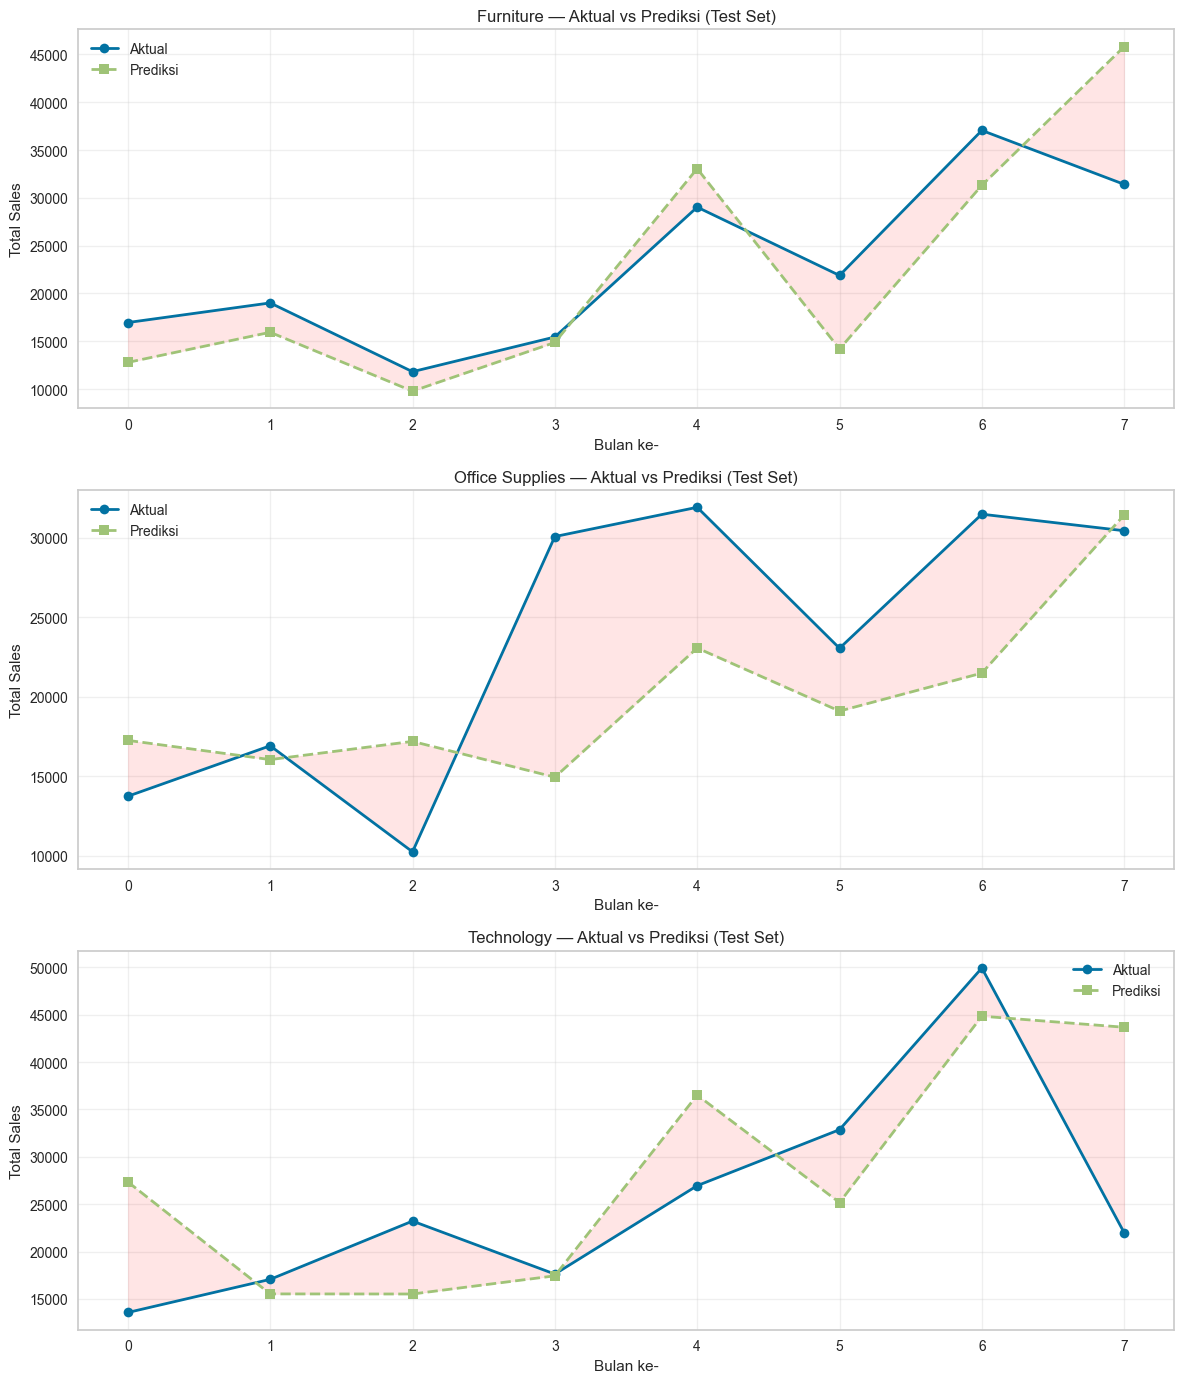

In [64]:
fig, axes = plt.subplots(3, 1, figsize=(12, 14))

for ax, (cat, info) in zip(axes, tuned_models.items()):
    train = categories[cat][0]
    val   = categories[cat][1]
    test  = categories[cat][2]
    
    # Prediksi test set
    train_val = np.concatenate([train, val])
    
    if info['type'] == 'arima':
        params = info['params']
        m = ARIMA(train_val,
                  order=(params['p'], params['d'], params['q']),
                  seasonal_order=(params['seasonal_P'], params['seasonal_D'], params['seasonal_Q'], 12)).fit()
        pred_test = m.forecast(steps=len(test))
    elif info['type'] == 'theta':
        params = info['params']
        m = ThetaModel(train_val, period=params['period'],
                       deseasonalize=params['deseasonalize']).fit()
        pred_test = m.forecast(steps=len(test))
    elif info['type'] == 'omp':
        params = info['params']
        omp, scaler, seas_comp, trend_coefs, detrend_tv, deseas_tv = train_omp(
            train_val, period=params['period'],
            n_lags=params['n_lags'], n_nonzero_coefs=params['n_nonzero_coefs'])
        pred_test = predict_omp(omp, scaler, train_val, seas_comp, trend_coefs,
                                detrend_tv, steps=len(test),
                                period=params['period'], n_lags=params['n_lags'])
    
    x = range(len(test))
    ax.plot(x, test, label='Aktual', marker='o', linewidth=2)
    ax.plot(x, pred_test, label='Prediksi', marker='s', linestyle='--', linewidth=2)
    ax.fill_between(x, test, pred_test, alpha=0.1, color='red')
    ax.set_title(f'{cat} — Aktual vs Prediksi (Test Set)')
    ax.set_xlabel('Bulan ke-')
    ax.set_ylabel('Total Sales')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("aktual_vs_prediksi.png", dpi=150, bbox_inches='tight')
plt.show()

#### Cell 15 — Perbandingan Antar Model (Bar Chart)

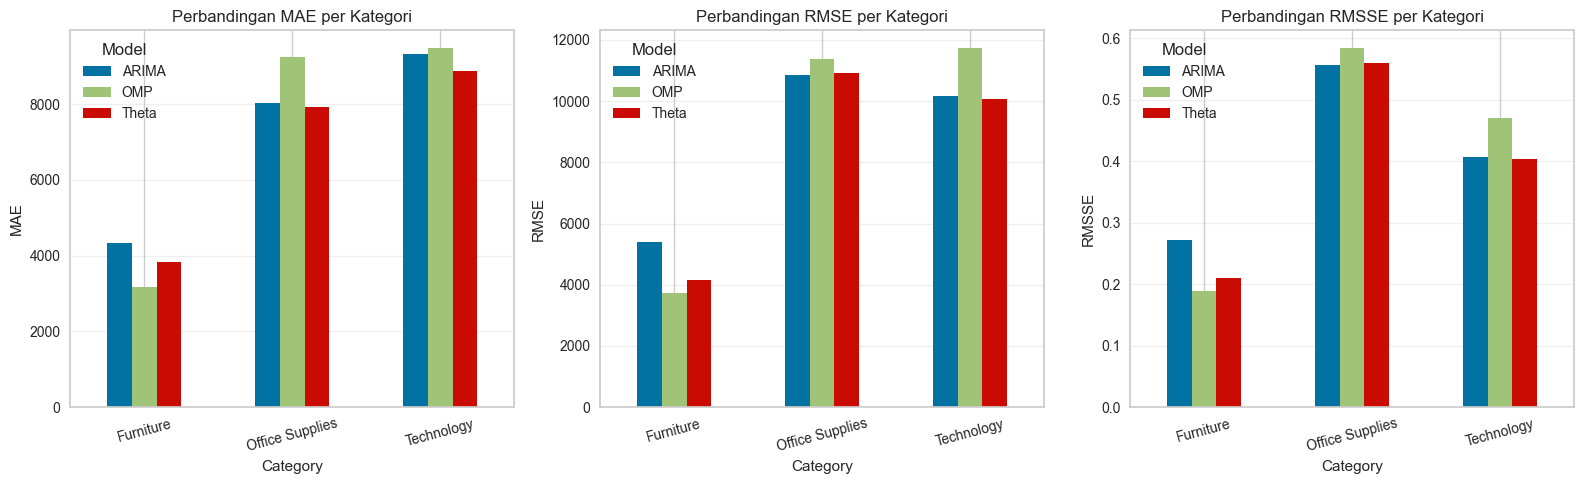

In [65]:
# Kumpulkan semua metrics dari results (sebelum tuning)
rows = []
for cat, models in results.items():
    for model_name, info in models.items():
        row = {'Category': cat, 'Model': model_name}
        row.update(info['metrics'])
        rows.append(row)

df_metrics = pd.DataFrame(rows)

# Bar chart per metric
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric in zip(axes, ['MAE', 'RMSE', 'RMSSE']):
    df_pivot = df_metrics.pivot(index='Category', columns='Model', values=metric)
    df_pivot.plot(kind='bar', ax=ax, rot=15)
    ax.set_title(f'Perbandingan {metric} per Kategori')
    ax.set_ylabel(metric)
    ax.legend(title='Model')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("perbandingan_model.png", dpi=150, bbox_inches='tight')
plt.show()

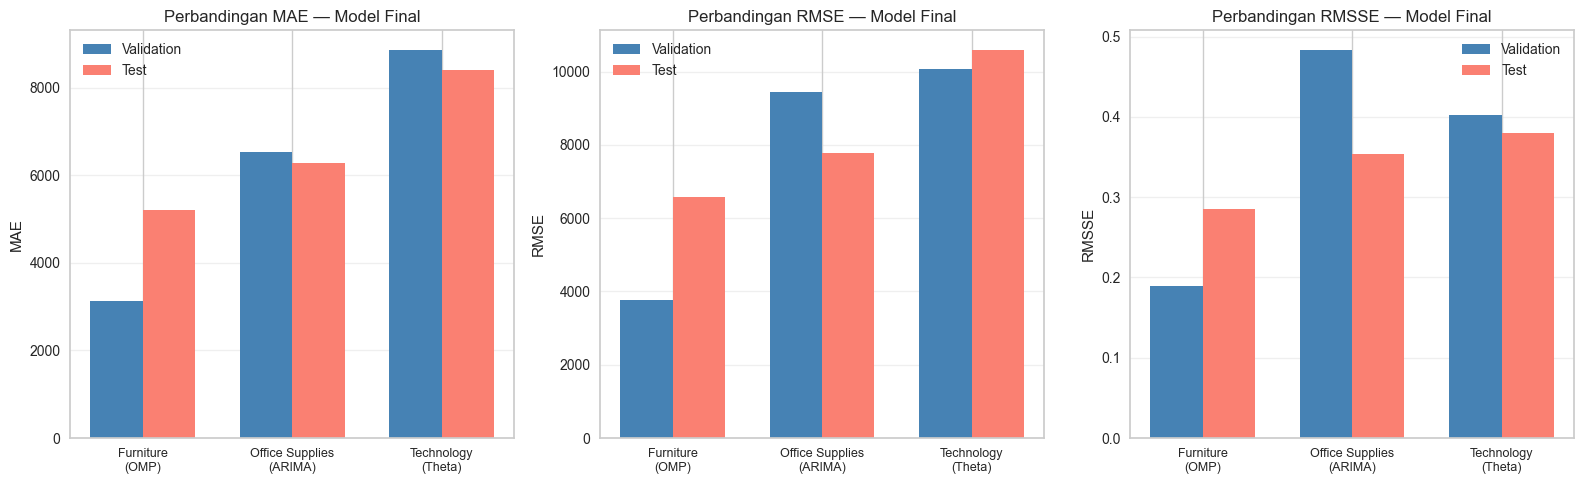

In [66]:
# Kumpulkan metrics 3 model final
rows_final = []
for cat, info in tuned_models.items():
    row = {
        'Category': cat,
        'Model': info['name'],
        'MAE_val':   info['val_metrics']['MAE'],
        'RMSE_val':  info['val_metrics']['RMSE'],
        'RMSSE_val': info['val_metrics']['RMSSE'],
        'MAE_test':  info['test_metrics']['MAE'],
        'RMSE_test': info['test_metrics']['RMSE'],
        'RMSSE_test':info['test_metrics']['RMSSE'],
    }
    rows_final.append(row)

df_final = pd.DataFrame(rows_final)
df_final['Label'] = df_final['Category'] + '\n(' + df_final['Model'] + ')'

x = np.arange(len(df_final))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric in zip(axes, ['MAE', 'RMSE', 'RMSSE']):
    bars1 = ax.bar(x - width/2, df_final[f'{metric}_val'],  width, label='Validation', color='steelblue')
    bars2 = ax.bar(x + width/2, df_final[f'{metric}_test'], width, label='Test', color='salmon')
    
    ax.set_title(f'Perbandingan {metric} — Model Final')
    ax.set_ylabel(metric)
    ax.set_xticks(x)
    ax.set_xticklabels(df_final['Label'], fontsize=9)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("perbandingan_model_final.png", dpi=150, bbox_inches='tight')
plt.show()

#### Cell 16 — Forecast 6 Bulan ke Depan

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mlflow

# Tentukan periode forecast
last_date = pd.Period("2017-12", freq="M")
forecast_periods = pd.period_range(start=last_date + 1, periods=6, freq="M")
print("Periode forecast:", forecast_periods)

forecast_results = {}

for cat, info in tuned_models.items():
    cat_slug   = cat.replace(" ", "_")
    model_type = info['type']
    params     = info['params']

    # Gunakan SELURUH data (train+val+test) untuk refit final sebelum forecast
    full_series = np.concatenate([
        categories[cat][0],  # train
        categories[cat][1],  # val
        categories[cat][2],  # test
    ])

    print(f"\nForecasting {cat} dengan {info['name']}...")

    with mlflow.start_run(run_name=f"FORECAST_{info['name']}_{cat_slug}"):

        if model_type == 'arima':
            final_model = ARIMA(
                full_series,
                order=(params['p'], params['d'], params['q']),
                seasonal_order=(params['seasonal_P'], params['seasonal_D'], params['seasonal_Q'], 12)
                    ).fit()
            forecast_values = final_model.forecast(steps=6)

            # Confidence interval
            forecast_result_obj = final_model.get_forecast(steps=6)
            forecast_ci         = forecast_result_obj.conf_int(alpha=0.05)

            if hasattr(forecast_ci, 'iloc'):        # DataFrame
                lower = forecast_ci.iloc[:, 0].values
                upper = forecast_ci.iloc[:, 1].values
            elif hasattr(forecast_ci, 'ndim'):      # numpy array
                lower = forecast_ci[:, 0]
                upper = forecast_ci[:, 1]
            else:                                   # fallback
                rmse_test = info['test_metrics']['RMSE']
                lower = forecast_values - 1.96 * rmse_test
                upper = forecast_values + 1.96 * rmse_test

        elif model_type == 'theta':
            final_model = ThetaModel(
                full_series,
                period=params['period'],
                deseasonalize=params['deseasonalize']
            ).fit()
            forecast_summary = final_model.forecast(steps=6, theta=2)

            # Theta support CI via summary_frame
            try:
                sf = final_model.summary_frame(steps=6, theta=2, alpha=0.05)
                forecast_values = sf['mean'].values
                lower           = sf['mean_ci_lower'].values
                upper           = sf['mean_ci_upper'].values
            except Exception:
                forecast_values = np.array(forecast_summary)
                lower           = forecast_values * 0.85  # fallback ±15%
                upper           = forecast_values * 1.15

        elif model_type == 'omp':
            omp, scaler, seas_comp, trend_coefs, detrend_full, deseas_full = train_omp(
                full_series,
                period=params['period'],
                n_lags=params['n_lags'],
                n_nonzero_coefs=params['n_nonzero_coefs']
            )
            forecast_values = predict_omp(
                omp, scaler, full_series, seas_comp, trend_coefs,
                detrend_full, steps=6,
                period=params['period'], n_lags=params['n_lags']
            )
            # OMP tidak punya CI bawaan — gunakan RMSE test sebagai proxy
            rmse_test = info['test_metrics']['RMSE']
            lower = np.maximum(forecast_values - 1.96 * rmse_test, 0)
            upper     = forecast_values + 1.96 * rmse_test

        forecast_results[cat] = {
            'periods': forecast_periods,
            'forecast': forecast_values,
            'lower':    lower,
            'upper':    upper,
        }

        # Log ke MLflow
        mlflow.log_param("model",    info['name'])
        mlflow.log_param("category", cat)
        mlflow.log_param("horizon",  6)
        for i, (p, f) in enumerate(zip(forecast_periods, forecast_values)):
            mlflow.log_metric(f"forecast_{p}", round(float(f), 2))

        print(f"  {'Periode':<12} {'Forecast':>12} {'Lower 95%':>12} {'Upper 95%':>12}")
        print(f"  {'-'*50}")
        for p, f, lo, hi in zip(forecast_periods, forecast_values, lower, upper):
            print(f"  {str(p):<12} {f:>12,.0f} {lo:>12,.0f} {hi:>12,.0f}")


Periode forecast: PeriodIndex(['2018-01', '2018-02', '2018-03', '2018-04', '2018-05', '2018-06'], dtype='period[M]')

Forecasting Furniture dengan OMP...
  Periode          Forecast    Lower 95%    Upper 95%
  --------------------------------------------------
  2018-01             9,742            0       22,656
  2018-02             5,095            0       18,010
  2018-03            14,590        1,675       27,505
  2018-04            13,255          340       26,170
  2018-05            16,228        3,313       29,143
  2018-06            16,926        4,011       29,841

Forecasting Office Supplies dengan ARIMA...
  Periode          Forecast    Lower 95%    Upper 95%
  --------------------------------------------------
  2018-01            25,546       12,237       38,855
  2018-02            18,224        4,600       31,848
  2018-03            21,996        8,065       35,927
  2018-04            22,274        8,042       36,506
  2018-05            21,565        7,038       

#### Cell 17 - Visualisasi

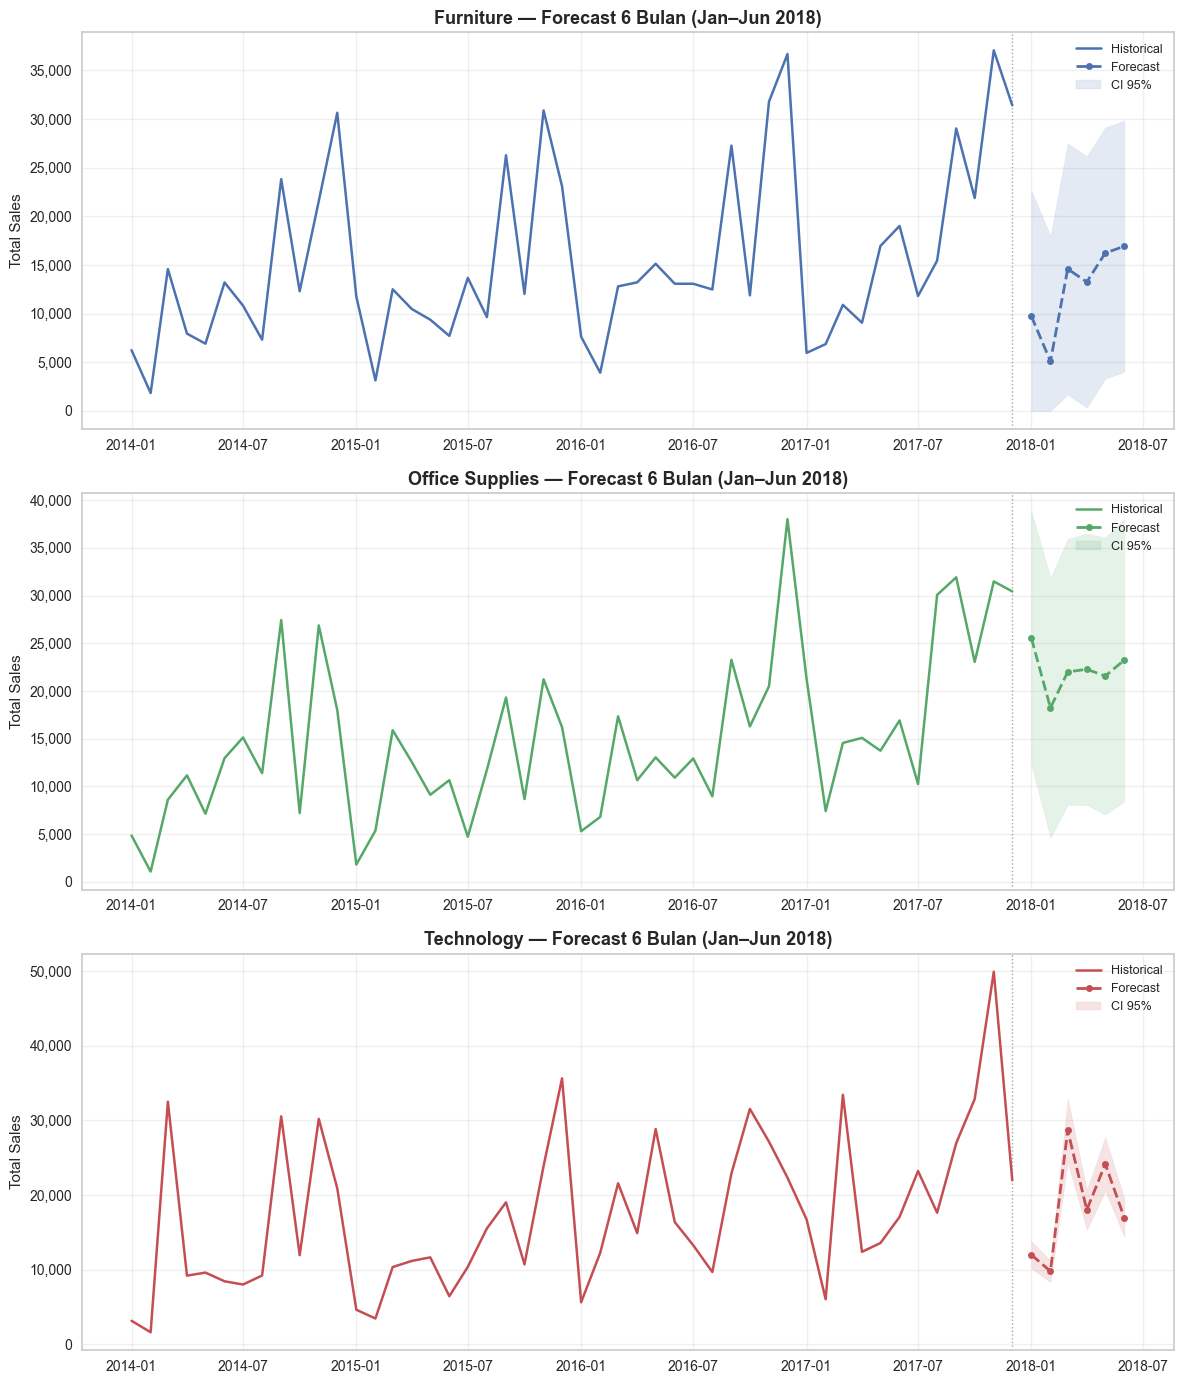


Plot tersimpan: forecast_6bulan.png


In [68]:
fig, axes = plt.subplots(3, 1, figsize=(12, 14))
colors = {'Furniture': '#4C72B0', 'Office Supplies': '#55A868', 'Technology': '#C44E52'}

for ax, (cat, res) in zip(axes, forecast_results.items()):
    full_series = np.concatenate([
        categories[cat][0],
        categories[cat][1],
        categories[cat][2],
    ])

    # Buat index waktu untuk historical
    # Sesuaikan start_period dengan data Anda
    hist_index = pd.period_range(start="2014-01", periods=len(full_series), freq="M")
    fc_index   = res['periods']

    color = colors[cat]

    # Plot historical
    ax.plot(hist_index.to_timestamp(), full_series,
            color=color, linewidth=1.8, label='Historical', zorder=3)

    # Plot forecast
    ax.plot(fc_index.to_timestamp(), res['forecast'],
            color=color, linewidth=2, linestyle='--', marker='o',
            markersize=5, label='Forecast', zorder=4)

    # Confidence interval
    ax.fill_between(fc_index.to_timestamp(),
                    res['lower'], res['upper'],
                    color=color, alpha=0.15, label='CI 95%')

    # Garis pemisah historical vs forecast
    ax.axvline(pd.Period("2017-12", freq="M").to_timestamp(),
               color='gray', linestyle=':', linewidth=1, alpha=0.7)

    ax.set_title(f"{cat} — Forecast 6 Bulan (Jan–Jun 2018)", fontsize=13, fontweight='bold')
    ax.set_ylabel("Total Sales")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.savefig("forecast_6bulan.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot tersimpan: forecast_6bulan.png")

#### Cell 18 — Simpan Model Forecast

In [69]:
os.makedirs("models/forecast", exist_ok=True)

for cat, res in forecast_results.items():
    cat_slug = cat.replace(" ", "_").lower()
    model_name = tuned_models[cat]['name'].lower()
    filename = f"models/forecast/forecast_{model_name}_{cat_slug}.pkl"
    
    forecast_df = pd.DataFrame({
        'period':   [str(p) for p in res['periods']],
        'forecast': res['forecast'],
        'lower':    res['lower'],
        'upper':    res['upper'],
    })
    
    with open(filename, "wb") as f:
        pickle.dump(forecast_df, f)
    
    print(f"Saved: {filename}")

print("\nIsi folder models/forecast:")
print(os.listdir("models/forecast"))

Saved: models/forecast/forecast_omp_furniture.pkl
Saved: models/forecast/forecast_arima_office_supplies.pkl
Saved: models/forecast/forecast_theta_technology.pkl

Isi folder models/forecast:
['forecast_arima_office_supplies.pkl', 'forecast_omp_furniture.pkl', 'forecast_theta_technology.pkl']
